> Part of **Complete Machine Learning Study Material** — split across per-chapter notebooks. See [`00_index.ipynb`](00_index.ipynb) for the notebook conventions, the per-concept template, the chapter coverage tracker and the cross-reference index.

## 11. Linear Regression

*Scope:* The first supervised model, derived from its objective, implemented twice from scratch, then matched against scikit-learn.

The first supervised model, and the one every later chapter is measured against. It is worth doing
properly because almost everything in Chapters 12 and 13 is a modification of it, and because it is the
only model in this material whose parameters can be solved for exactly.

This chapter follows the contract used by every algorithm chapter: **write down the objective, implement it
from scratch in NumPy, run the scikit-learn version, and check that the two agree.**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

RANDOM_STATE = 42
rng = np.random.default_rng(RANDOM_STATE)

np.set_printoptions(precision=4, suppress=True)
pd.set_option("display.width", 115)
sns.set_theme(style="whitegrid")
print("ready")

ready


### 11.1 The Model

Linear regression predicts a continuous target as a weighted sum of the features plus an intercept:

$$\hat{y} = w_1 x_1 + w_2 x_2 + \dots + w_p x_p + b = \mathbf{w} \cdot \mathbf{x} + b$$

Every symbol is §25.3's: $\mathbf{x}$ is one row of $X$, $\mathbf{w}$ is the coefficient vector, $b$ the
intercept. 2.1.1 already showed that the prediction *is* a dot product, and 2.2 that `X @ w` computes every
row's prediction at once.

| Name | When | Form |
|---|---|---|
| **Simple** linear regression | One feature | $\hat{y} = w_1 x_1 + b$ |
| **Multiple** linear regression | Several features | $\hat{y} = \mathbf{w} \cdot \mathbf{x} + b$ |
| **Polynomial** regression | Features raised to powers | Still linear regression — see 11.8 |

In [2]:
# Simple linear regression: one feature, a slope and an intercept.
n = 120
x = rng.uniform(0, 10, n)
y = 2.5 * x + 4.0 + rng.normal(0, 2.0, n)      # true slope 2.5, true intercept 4.0

X = x.reshape(-1, 1)
print("X shape:", X.shape, " y shape:", y.shape)   # (120, 1) (120,) - the 1.4 convention

X shape: (120, 1)  y shape: (120,)


#### 11.1.1 "Linear" means linear in the *parameters*

This is the most commonly misunderstood word in the subject. The model must be linear in $\mathbf{w}$; it
places no restriction whatsoever on what the features are.

| Model | Linear regression? | Why |
|---|---|---|
| $\hat{y} = w_1 x + b$ | Yes | Linear in $w_1$ |
| $\hat{y} = w_1 x + w_2 x^2 + b$ | **Yes** | Linear in $w_1, w_2$ — the *feature* is squared, not the weight |
| $\hat{y} = w_1 \log(x) + b$ | **Yes** | Same reason |
| $\hat{y} = w_1 x_1 x_2 + b$ | **Yes** | The interaction is a feature (6.4) |
| $\hat{y} = x^{w_1}$ | **No** | The parameter is in the exponent |
| $\hat{y} = \sin(w_1 x)$ | **No** | The parameter is inside a non-linear function |

The practical consequence is large: a "linear" model can fit curves, interactions and thresholds, provided
you construct the right features (Chapter 6). What it cannot do is *discover* them.

### 11.2 The Least Squares Objective

The model family is fixed; what remains is choosing $\mathbf{w}$ and $b$. **Ordinary least squares** (OLS)
chooses the values that minimize the mean squared error:

$$J(\mathbf{w}) = \frac{1}{n}\sum_{i=1}^{n}\left(\hat{y}^{(i)} - y^{(i)}\right)^2 = \frac{1}{n}\lVert X\mathbf{w} - y \rVert^2$$

**Why squared error and not absolute error?** Three reasons, in increasing order of honesty:

| Reason | Weight |
|---|---|
| It is differentiable everywhere, so calculus applies (10.2.1) | Real |
| It has a unique closed-form minimizer (11.3) | Real |
| It is the maximum-likelihood estimate **if** the noise is Gaussian | Real, and an assumption (11.6) |

The third is the principled one and is worth stating precisely: if $y = \mathbf{w}\cdot\mathbf{x} + b +
\varepsilon$ with $\varepsilon \sim \mathcal{N}(0, \sigma^2)$, then maximizing the likelihood of the
observed data is *exactly* minimizing the squared error. Squared loss is not arbitrary; it encodes a belief
about the noise. When that belief is wrong — heavy tails, outliers — Huber loss (10.2.1) is the better
choice.

#### 11.2.1 Absorbing the intercept

The algebra is cleaner if the intercept becomes just another coefficient. Prepend a column of ones to $X$;
then $b$ is $w_0$ and the model is simply $\hat{y} = X\mathbf{w}$.

In [3]:
def add_intercept(X):
    return np.column_stack([np.ones(len(X)), X])


X_design = add_intercept(X)
print(X_design[:3])          # first column is all ones
print("shape:", X_design.shape)   # (120, 2) -> intercept + 1 feature

[[1.     7.7396]
 [1.     4.3888]
 [1.     8.586 ]]
shape: (120, 2)


#### 11.2.2 Deriving the minimizer

Write the objective in matrix form (dropping the $1/n$, which does not change the location of the minimum):

$$J(\mathbf{w}) = (X\mathbf{w} - y)^\top(X\mathbf{w} - y) = \mathbf{w}^\top X^\top X \mathbf{w} - 2\mathbf{w}^\top X^\top y + y^\top y$$

Differentiate with respect to $\mathbf{w}$ (2.6.1) and set the gradient to zero:

$$\nabla J = 2X^\top X\mathbf{w} - 2X^\top y = 0 \quad \Longrightarrow \quad X^\top X \mathbf{w} = X^\top y$$

That last equation is the **normal equation**. When $X^\top X$ is invertible it gives

$$\boxed{\;\mathbf{w} = (X^\top X)^{-1} X^\top y\;}$$

The objective is convex (10.3) — $X^\top X$ is positive semi-definite — so this stationary point is the
global minimum, not merely a local one. That is why linear regression has no learning rate, no
initialization and no random seed.

The gradient derived here is the one 2.6.2 verified numerically, up to the $2/n$ factor.

In [4]:
def mse(X, y, w):
    return np.mean((X @ w - y) ** 2)


def mse_gradient(X, y, w):
    return 2 / len(y) * X.T @ (X @ w - y)


# Re-verify the gradient numerically (2.6.2's habit, applied to this chapter's objective).
w_test = np.array([1.0, 1.0])
h = 1e-6
numerical = np.array([
    (mse(X_design, y, w_test + h * np.eye(2)[j]) - mse(X_design, y, w_test - h * np.eye(2)[j])) / (2 * h)
    for j in range(2)
])

print("analytic gradient :", mse_gradient(X_design, y, w_test))
print("numerical gradient:", numerical)
print("agree:", np.allclose(mse_gradient(X_design, y, w_test), numerical))

analytic gradient : [ -20.9254 -126.6088]
numerical gradient: [ -20.9254 -126.6088]
agree: True


### 11.3 The Normal Equation from Scratch

Four lines of NumPy. Note that it uses `solve`, not `inv` — 2.4's rule, and the reason is visible in 2.9.1
where the explicit inverse corrupted coefficients the solver got right.

In [5]:
def fit_normal_equation(X, y):
    """Solve X^T X w = X^T y.  X must already include an intercept column."""
    return np.linalg.solve(X.T @ X, X.T @ y)


w_hat = fit_normal_equation(X_design, y)

print(f"intercept b : {w_hat[0]:.4f}   (true 4.0)")
print(f"slope     w1: {w_hat[1]:.4f}   (true 2.5)")
print(f"training MSE: {mse(X_design, y, w_hat):.4f}")

intercept b : 3.9960   (true 4.0)
slope     w1: 2.4972   (true 2.5)
training MSE: 4.0619


**Step 4 of the contract: check it against scikit-learn.**

In [6]:
from sklearn.linear_model import LinearRegression

sk = LinearRegression().fit(X, y)          # sklearn adds its own intercept

print(f"from scratch : intercept {w_hat[0]:.10f}   slope {w_hat[1]:.10f}")
print(f"scikit-learn : intercept {sk.intercept_:.10f}   slope {sk.coef_[0]:.10f}")
print("\nidentical:", np.allclose(w_hat, np.r_[sk.intercept_, sk.coef_]))

from scratch : intercept 3.9960171952   slope 2.4971905100
scikit-learn : intercept 3.9960171952   slope 2.4971905100

identical: True


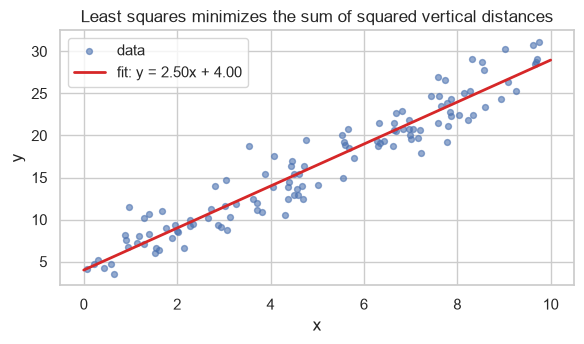

In [7]:
fig, ax = plt.subplots(figsize=(6, 3.6))
ax.scatter(x, y, s=18, alpha=0.6, label="data")
grid = np.linspace(0, 10, 100)
ax.plot(grid, w_hat[0] + w_hat[1] * grid, color="tab:red", lw=2,
        label=f"fit: y = {w_hat[1]:.2f}x + {w_hat[0]:.2f}")
ax.set_xlabel("x"); ax.set_ylabel("y")
ax.set_title("Least squares minimizes the sum of squared vertical distances")
ax.legend()
fig.tight_layout()
plt.show()

#### 11.3.1 Multiple features

Nothing in `fit_normal_equation` assumed one feature. The same four lines handle any number.

In [8]:
n_multi = 300
X_multi = rng.normal(size=(n_multi, 4))
W_TRUE = np.array([6.0, 2.0, -1.5, 0.8, 0.0])        # intercept first, last feature is irrelevant
y_multi = add_intercept(X_multi) @ W_TRUE + rng.normal(0, 0.5, n_multi)

w_multi = fit_normal_equation(add_intercept(X_multi), y_multi)
sk_multi = LinearRegression().fit(X_multi, y_multi)

print("true        :", W_TRUE)
print("from scratch:", w_multi)
print("scikit-learn:", np.r_[sk_multi.intercept_, sk_multi.coef_])
print("\nmatch:", np.allclose(w_multi, np.r_[sk_multi.intercept_, sk_multi.coef_]))

true        : [ 6.   2.  -1.5  0.8  0. ]
from scratch: [ 5.9365  1.9757 -1.4779  0.8057  0.0055]
scikit-learn: [ 5.9365  1.9757 -1.4779  0.8057  0.0055]

match: True


The fourth feature's true coefficient is 0 and the fit recovers something small but non-zero. That is
sampling noise, not a mistake — and it is exactly what Chapter 12's L1 penalty is built to drive to a
genuine zero.

#### 11.3.2 Cost, and when it breaks

| Step | Cost |
|---|---|
| Form $X^\top X$ | $O(np^2)$ |
| Solve the system | $O(p^3)$ |
| **Total** | $O(np^2 + p^3)$ |

Cubic in the number of features, linear in rows. This is 10.8's table made concrete: fine for hundreds of
features, impossible for millions, and it requires all of $X$ in memory at once.

It also breaks when $X^\top X$ is singular (2.4.1) — but it breaks in **two different ways**, and only one
of them announces itself.

**Case 1 — an exactly duplicated feature.** The determinant is exactly zero and `solve` refuses.

In [9]:
X_dup = rng.normal(size=(50, 3))
X_dup = np.column_stack([X_dup, X_dup[:, 0]])          # column 3 is an exact copy of column 0
y_dup = rng.normal(size=50)
design_dup = add_intercept(X_dup)

A = design_dup.T @ design_dup
print(f"rank {np.linalg.matrix_rank(A)} of {A.shape[0]}   det {np.linalg.det(A):.1f}")

try:
    fit_normal_equation(design_dup, y_dup)
except np.linalg.LinAlgError as e:
    print("normal equation ->", type(e).__name__, ":", e)

rank 4 of 5   det 0.0
normal equation -> LinAlgError : Singular matrix


**Case 2 — more features than rows.** This is the dangerous one: `solve` does **not** raise, and returns a
perfectly valid-looking answer.

In [10]:
X_wide = rng.normal(size=(10, 20))            # 20 features, 10 rows: p > n
y_wide = rng.normal(size=10)
design_wide = add_intercept(X_wide)

A_wide = design_wide.T @ design_wide
print(f"X^T X is {A_wide.shape[0]}x{A_wide.shape[1]}, rank {np.linalg.matrix_rank(A_wide)}"
      f"   det {np.linalg.det(A_wide):.3e}")

w_wide = fit_normal_equation(design_wide, y_wide)      # no exception at all
print(f"solve returned a vector, max |w| = {np.abs(w_wide).max():.3f}")
print(f"training residual, max |Xw - y| = {np.abs(design_wide @ w_wide - y_wide).max():.2e}")

X^T X is 21x21, rank 10   det 5.960e-154
solve returned a vector, max |w| = 2.464
training residual, max |Xw - y| = 1.39e-15


The determinant is $10^{-155}$ — numerically zero but not *exactly* zero, so LAPACK proceeds. And the
returned coefficients fit the training data **perfectly**, to fifteen decimal places, on ten rows of pure
noise.

That is not a solution; it is one arbitrary member of an infinite family of exact interpolations (2.9.2's
non-identifiability, in its most extreme form). The training error is zero, the test error would be
catastrophic, and nothing raised a warning. This is precisely the regime Chapter 12's penalties exist for.

In [11]:
print("lstsq's minimum-norm answer is smaller and more defensible:")
w_lstsq = np.linalg.lstsq(design_wide, y_wide, rcond=None)[0]
print(f"  max |w|, solve : {np.abs(w_wide).max():>8.3f}")
print(f"  max |w|, lstsq : {np.abs(w_lstsq).max():>8.3f}")
print(f"  both fit the training data exactly: "
      f"{np.abs(design_wide @ w_lstsq - y_wide).max():.2e}")

lstsq's minimum-norm answer is smaller and more defensible:
  max |w|, solve :    2.464
  max |w|, lstsq :    0.481
  both fit the training data exactly: 7.55e-15


`LinearRegression` uses `scipy.linalg.lstsq` internally rather than the normal equation, which is why it
succeeds on data where the textbook formula raises. 2.9.1 showed the cost of that convenience: it returns
*an* answer, and on collinear data that answer's individual coefficients are not interpretable.

### 11.4 Gradient Descent for Linear Regression

The closed form is exact, so gradient descent is unnecessary here — which makes this the ideal place to
check that the iterative machinery of Chapter 10 converges to the known right answer.

In [12]:
def fit_gradient_descent(X, y, lr=0.05, n_iter=2000):
    w = np.zeros(X.shape[1])
    for _ in range(n_iter):
        w -= lr * mse_gradient(X, y, w)
    return w


w_gd = fit_gradient_descent(add_intercept(X_multi), y_multi)

print("normal equation :", w_multi)
print("gradient descent:", w_gd)
print("\nagree to 6 decimals:", np.allclose(w_multi, w_gd, atol=1e-6))
print("difference       :", np.abs(w_multi - w_gd).max())

normal equation : [ 5.9365  1.9757 -1.4779  0.8057  0.0055]
gradient descent: [ 5.9365  1.9757 -1.4779  0.8057  0.0055]

agree to 6 decimals: True
difference       : 4.440892098500626e-15


Two exact methods, one iterative approximation, one answer. That agreement is the contract's fourth step,
and it is what licenses reusing either implementation in Chapter 12 and 13.

For genuinely large problems scikit-learn exposes the stochastic version (10.5) as `SGDRegressor`.

In [13]:
from sklearn.linear_model import SGDRegressor
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

sgd = make_pipeline(StandardScaler(),
                    SGDRegressor(loss="squared_error", penalty=None, max_iter=5000,
                                 tol=1e-6, random_state=RANDOM_STATE))
sgd.fit(X_multi, y_multi)

exact_pred = LinearRegression().fit(X_multi, y_multi).predict(X_multi)
sgd_pred = sgd.predict(X_multi)

print(f"exact vs SGD, max prediction difference: {np.abs(exact_pred - sgd_pred).max():.6f}")
print(f"exact MSE : {np.mean((y_multi - exact_pred) ** 2):.6f}")
print(f"SGD   MSE : {np.mean((y_multi - sgd_pred) ** 2):.6f}")

exact vs SGD, max prediction difference: 0.007274
exact MSE : 0.260080
SGD   MSE : 0.260086


**`SGDRegressor` requires scaled features** (5.5, 10.6.1); without the scaler it will either diverge or
crawl. `LinearRegression` does not, because a closed-form solve is unaffected by feature scale.

### 11.5 Linear Regression in scikit-learn

| Attribute / argument | Is |
|---|---|
| `coef_` | The learned $\mathbf{w}$, one per feature (trailing underscore = learned, 3.7.1) |
| `intercept_` | The learned $b$ |
| `fit_intercept=True` | Whether to fit $b$ at all; `False` forces the line through the origin |
| `positive=False` | Constrain all coefficients to be non-negative |
| `.predict(X)` | $X\mathbf{w} + b$ |
| `.score(X, y)` | **R²**, not MSE (8.4.2) |

In [14]:
model = LinearRegression().fit(X_multi, y_multi)

print("coef_      :", model.coef_)
print("intercept_ :", round(model.intercept_, 4))
print("R^2 (score):", round(model.score(X_multi, y_multi), 4))
print("n_features_in_:", model.n_features_in_)

coef_      : [ 1.9757 -1.4779  0.8057  0.0055]
intercept_ : 5.9365
R^2 (score): 0.9567
n_features_in_: 4


**Common mistake — `fit_intercept=False` on data that is not centred.** Forcing the line through the origin
is occasionally correct (a physical law with no offset) and usually wrong. The cost is not subtle.

In [15]:
x_off = rng.uniform(5, 15, 100).reshape(-1, 1)
y_off = 2.0 * x_off.ravel() + 50.0 + rng.normal(0, 1, 100)    # large intercept

with_b = LinearRegression().fit(x_off, y_off)
without_b = LinearRegression(fit_intercept=False).fit(x_off, y_off)

print(f"true slope 2.0, true intercept 50.0")
print(f"fit_intercept=True   slope {with_b.coef_[0]:.3f}   R^2 {with_b.score(x_off, y_off):.4f}")
print(f"fit_intercept=False  slope {without_b.coef_[0]:.3f}   R^2 {without_b.score(x_off, y_off):.4f}")

true slope 2.0, true intercept 50.0
fit_intercept=True   slope 1.974   R^2 0.9607
fit_intercept=False  slope 6.652   R^2 -4.8959


Forced through the origin, the slope absorbs the intercept and lands at 6.9 instead of 2.0 — a coefficient
that is simply wrong, from a model whose R² still looks respectable.

### 11.6 Assumptions and Residual Diagnostics

OLS makes five assumptions. They matter to different degrees depending on what you want from the model, and
conflating those two cases is the source of most confusion about them.

| # | Assumption | Violated means | Breaks prediction? | Breaks inference? |
|---|---|---|---|---|
| 1 | **Linearity** — the relationship is linear in the parameters | The model is systematically wrong | **Yes** | Yes |
| 2 | **Independence** — errors are uncorrelated | Repeated or time-ordered structure ignored | Somewhat | **Yes** |
| 3 | **Homoscedasticity** — constant error variance | Errors grow with the prediction | No | **Yes** |
| 4 | **Normality of residuals** | Errors are skewed or heavy-tailed | **No** | Yes, in small samples |
| 5 | **No perfect multicollinearity** | Features are redundant (11.7) | No | **Yes** |

Read the last two columns. **If you only want predictions, assumptions 3, 4 and 5 barely matter.** They
matter for *inference* — p-values, confidence intervals, and any statement of the form "this feature has
this effect". Chapters 8 and 9 never needed them; 11.9 does.

The residual plot is the workhorse diagnostic for 1 and 3.

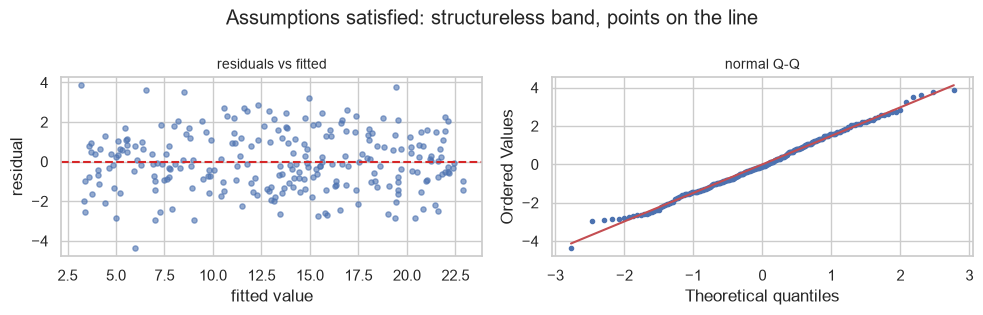

In [16]:
def residual_panel(X, y, title):
    """Fit OLS and draw the two standard residual diagnostics."""
    m = LinearRegression().fit(X, y)
    fitted = m.predict(X)
    resid = y - fitted

    fig, axes = plt.subplots(1, 2, figsize=(10, 3.2))
    axes[0].scatter(fitted, resid, s=14, alpha=0.6)
    axes[0].axhline(0, color="tab:red", ls="--")
    axes[0].set_xlabel("fitted value"); axes[0].set_ylabel("residual")
    axes[0].set_title("residuals vs fitted", fontsize=10)

    from scipy import stats
    stats.probplot(resid, dist="norm", plot=axes[1])
    axes[1].set_title("normal Q-Q", fontsize=10)
    axes[1].get_lines()[0].set_markersize(3)

    fig.suptitle(title)
    fig.tight_layout()
    plt.show()
    return resid


x_ok = rng.uniform(0, 10, 250)
y_ok = 2.0 * x_ok + 3.0 + rng.normal(0, 1.5, 250)
_ = residual_panel(x_ok.reshape(-1, 1), y_ok, "Assumptions satisfied: structureless band, points on the line")

That is what "no problem" looks like: residuals scattered in a horizontal band with no pattern, and Q-Q
points sitting on the diagonal. Every violation below shows up as a departure from one of those two.

**Violation 1 — non-linearity.** The residuals curve.

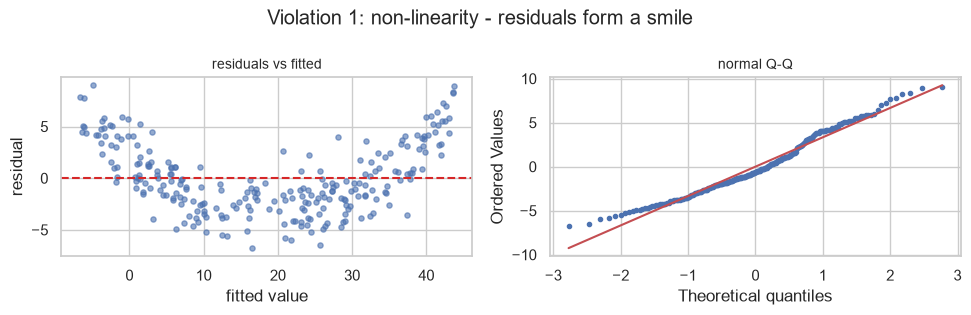

A U-shape in residuals vs fitted is the signature. Fix: add x^2 (11.8), or use a non-linear model.


In [17]:
x_curve = rng.uniform(0, 10, 250)
y_curve = 0.4 * x_curve ** 2 + 1.0 * x_curve + rng.normal(0, 2.0, 250)   # genuinely quadratic
resid_curve = residual_panel(x_curve.reshape(-1, 1), y_curve,
                             "Violation 1: non-linearity - residuals form a smile")
print("A U-shape in residuals vs fitted is the signature. Fix: add x^2 (11.8), or use a non-linear model.")

**Violation 3 — heteroscedasticity.** The residual spread grows with the fitted value, producing a fan or
cone. Very common on monetary quantities, where a 10% error on a large value is much larger in absolute
terms than on a small one.

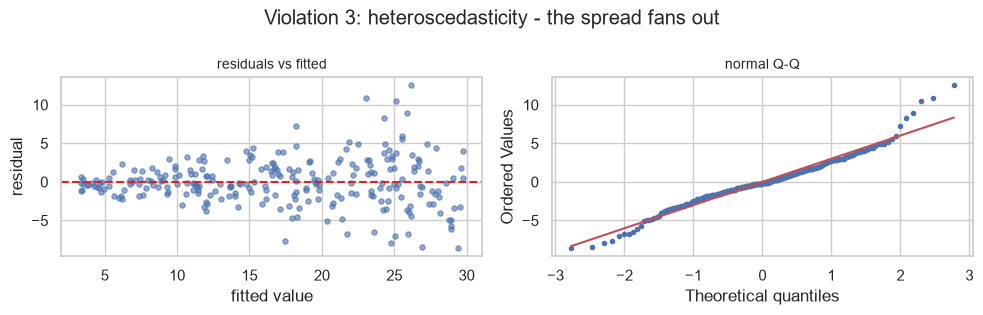

In [18]:
x_fan = rng.uniform(1, 10, 250)
y_fan = 3.0 * x_fan + rng.normal(0, 0.5 * x_fan, 250)    # noise scales with x
_ = residual_panel(x_fan.reshape(-1, 1), y_fan,
                   "Violation 3: heteroscedasticity - the spread fans out")

The formal test is Breusch–Pagan, which regresses the squared residuals on the features and asks whether
that relationship is real.

In [19]:
import statsmodels.api as sm
from statsmodels.stats.diagnostic import het_breuschpagan

for label, xv, yv in (("constant variance", x_ok, y_ok), ("fanning variance", x_fan, y_fan)):
    design = sm.add_constant(xv)
    fitted_model = sm.OLS(yv, design).fit()
    _, p_value, _, _ = het_breuschpagan(fitted_model.resid, design)
    verdict = "heteroscedastic" if p_value < 0.05 else "no evidence of heteroscedasticity"
    print(f"{label:<20} Breusch-Pagan p = {p_value:.2e}  -> {verdict}")

constant variance    Breusch-Pagan p = 4.40e-01  -> no evidence of heteroscedasticity
fanning variance     Breusch-Pagan p = 2.37e-08  -> heteroscedastic


| Fix for heteroscedasticity | Does |
|---|---|
| Log-transform the target | Often converts multiplicative noise to additive (5.6) |
| Weighted least squares | Weights each row by $1/\sigma_i^2$ |
| Robust (HC) standard errors | Leaves coefficients alone, corrects their standard errors |

The third is usually the right answer when you only need inference: the coefficients are still unbiased, so
only the uncertainty around them needs repairing.

In [20]:
design_fan = sm.add_constant(x_fan)
plain = sm.OLS(y_fan, design_fan).fit()
robust = sm.OLS(y_fan, design_fan).fit(cov_type="HC3")

print(f"slope estimate          : {plain.params[1]:.4f}  (identical in both fits)")
print(f"standard error, plain   : {plain.bse[1]:.4f}")
print(f"standard error, HC3     : {robust.bse[1]:.4f}   <- corrected for the fanning")
print(f"95% CI, plain : [{plain.conf_int()[1][0]:.3f}, {plain.conf_int()[1][1]:.3f}]")
print(f"95% CI, HC3   : [{robust.conf_int()[1][0]:.3f}, {robust.conf_int()[1][1]:.3f}]")

slope estimate          : 2.9469  (identical in both fits)
standard error, plain   : 0.0753
standard error, HC3     : 0.0766   <- corrected for the fanning
95% CI, plain : [2.799, 3.095]
95% CI, HC3   : [2.797, 3.097]


**Violation 4 — non-normal residuals.** Worth being precise about, because it is the most over-worried
assumption in applied work. Normality is **not** needed for the coefficients to be unbiased, and by the
central limit theorem (2.8.3) the standard errors become approximately valid in large samples regardless.
It matters for exact inference in small samples, and heavy-tailed residuals are a warning that squared loss
is being dominated by a few points (10.2.1).

In [21]:
from scipy import stats

x_heavy = rng.uniform(0, 10, 200)
y_heavy = 2.0 * x_heavy + 3.0 + stats.t(df=2).rvs(200, random_state=RANDOM_STATE) * 2   # heavy tails

for label, xv, yv in (("normal residuals", x_ok, y_ok), ("heavy-tailed residuals", x_heavy, y_heavy)):
    m = LinearRegression().fit(xv.reshape(-1, 1), yv)
    r = yv - m.predict(xv.reshape(-1, 1))
    print(f"{label:<24} slope {m.coef_[0]:.3f}   "
          f"Shapiro-Wilk p {stats.shapiro(r).pvalue:.2e}   kurtosis {stats.kurtosis(r):.2f}")

normal residuals         slope 1.986   Shapiro-Wilk p 5.94e-01   kurtosis -0.28
heavy-tailed residuals   slope 1.983   Shapiro-Wilk p 1.46e-13   kurtosis 8.43


Both slopes are close to the true 2.0. The heavy-tailed fit is *unbiased* and merely noisier — which is the
whole point: non-normality degrades precision, not correctness.

### 11.7 Multicollinearity and the Variance Inflation Factor

**Multicollinearity** is a feature being predictable from the other features. 2.9 showed the consequences
concretely: the coefficients become unstable and, in the extreme, non-identifiable.

The **variance inflation factor** quantifies it for each feature. Regress feature $j$ on all the other
features, take that regression's $R^2_j$, and compute

$$\text{VIF}_j = \frac{1}{1 - R^2_j}$$

If feature $j$ is unrelated to the others, $R^2_j = 0$ and $\text{VIF}_j = 1$. If it is perfectly
predictable, $R^2_j \to 1$ and the VIF explodes.

| VIF | Reading |
|---|---|
| 1 | No collinearity |
| 1–5 | Moderate; usually acceptable |
| 5–10 | Concerning |
| > 10 | Severe — the coefficient is not interpretable |

In [22]:
def vif_from_scratch(X):
    """VIF for every column of X (no intercept column)."""
    vifs = []
    for j in range(X.shape[1]):
        others = np.delete(X, j, axis=1)
        r2 = LinearRegression().fit(others, X[:, j]).score(others, X[:, j])
        vifs.append(1 / (1 - r2))
    return np.array(vifs)


# Three independent features, plus one that is nearly the sum of the first two.
n_v = 400
f1, f2, f3 = rng.normal(size=(3, n_v))
f4 = f1 + f2 + rng.normal(0, 0.1, n_v)        # almost a linear combination
X_collinear = np.column_stack([f1, f2, f3, f4])

print("VIF from scratch:", vif_from_scratch(X_collinear).round(2))

VIF from scratch: [112.15 117.91   1.01 239.29]


In [23]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

design = sm.add_constant(X_collinear)
sm_vifs = np.array([variance_inflation_factor(design, j) for j in range(1, design.shape[1])])

print("VIF from scratch :", vif_from_scratch(X_collinear).round(6))
print("VIF, statsmodels :", sm_vifs.round(6))
print("\nmatch:", np.allclose(vif_from_scratch(X_collinear), sm_vifs))

VIF from scratch : [112.1455 117.9119   1.0074 239.2894]
VIF, statsmodels : [112.1455 117.9119   1.0074 239.2894]

match: True


What collinearity actually damages is worth being precise about — and it is **not** prediction.

In [24]:
y_v = 2.0 * f1 - 1.0 * f2 + 0.5 * f3 + rng.normal(0, 0.5, n_v)      # f4 has NO true effect

clean = LinearRegression().fit(X_collinear[:, :3], y_v)
collinear = LinearRegression().fit(X_collinear, y_v)

print("true effects        : [ 2.0 -1.0  0.5   -  ]")
print("without f4          :", clean.coef_.round(3))
print("with f4 (VIF ~ 100) :", collinear.coef_.round(3))
print(f"\nR^2 without f4 : {clean.score(X_collinear[:, :3], y_v):.5f}")
print(f"R^2 with f4    : {collinear.score(X_collinear, y_v):.5f}   <- essentially unchanged")

true effects        : [ 2.0 -1.0  0.5   -  ]
without f4          : [ 1.99  -0.989  0.493]
with f4 (VIF ~ 100) : [ 2.03  -0.949  0.493 -0.04 ]

R^2 without f4 : 0.94057
R^2 with f4    : 0.94058   <- essentially unchanged


The predictions barely move; the coefficients move a great deal. **Multicollinearity is an interpretation
problem, not an accuracy problem.** If the model exists to predict, high VIF can be ignored. If anyone is
going to read a coefficient and act on it, it cannot.

The instability is the real symptom, and it is best shown by refitting on resampled data (2.9.1's test).

In [25]:
coef_clean, coef_collinear = [], []
for b in range(200):
    idx = rng.choice(n_v, n_v, replace=True)                 # bootstrap resample
    coef_clean.append(LinearRegression().fit(X_collinear[idx, :3], y_v[idx]).coef_[0])
    coef_collinear.append(LinearRegression().fit(X_collinear[idx], y_v[idx]).coef_[0])

print(f"coefficient on f1, without f4: {np.mean(coef_clean):.3f} +/- {np.std(coef_clean):.3f}")
print(f"coefficient on f1, with f4   : {np.mean(coef_collinear):.3f} +/- {np.std(coef_collinear):.3f}")
print(f"\nstandard deviation inflated by {np.std(coef_collinear) / np.std(coef_clean):.1f}x")

coefficient on f1, without f4: 1.990 +/- 0.028
coefficient on f1, with f4   : 2.023 +/- 0.277

standard deviation inflated by 9.8x


| Fix | When |
|---|---|
| Drop one of the correlated features | They are genuinely redundant (2.9.1) |
| Combine them into one (sum, ratio, mean) | The combination is what matters |
| PCA (7.5) | Many correlated features, interpretability not required |
| **Ridge** (12.2) | The correlation is real and nothing can be dropped |
| Do nothing | You only need predictions |

### 11.8 Polynomial Regression

11.1.1 established that raising a feature to a power keeps the model linear *in the parameters*. So fitting
a curve needs no new algorithm — only new columns (6.4).

In [26]:
from sklearn.preprocessing import PolynomialFeatures

x_poly = rng.uniform(-3, 3, 150)
y_poly = 0.5 * x_poly ** 3 - 2 * x_poly ** 2 + x_poly + 4 + rng.normal(0, 2.0, 150)
Xp = x_poly.reshape(-1, 1)

for degree in (1, 2, 3):
    model = make_pipeline(PolynomialFeatures(degree), LinearRegression()).fit(Xp, y_poly)
    print(f"degree {degree}   R^2 {model.score(Xp, y_poly):.4f}   "
          f"coefficients {model[-1].coef_.round(3)}")

degree 1   R^2 0.5051   coefficients [0.    3.459]
degree 2   R^2 0.8737   coefficients [ 0.    3.66 -1.92]
degree 3   R^2 0.9353   coefficients [ 0.     1.046 -1.988  0.509]


The degree-3 coefficients recover the generating polynomial's `[0, 1, -2, 0.5]` (the leading 0 is the
`PolynomialFeatures` bias column, which `LinearRegression` then ignores in favour of its own intercept).

Choosing the degree is 9.5's validation curve, and 9.5 also supplied the warning: take the
one-standard-error choice rather than the literal minimum.

In [27]:
from sklearn.model_selection import cross_val_score, KFold

cv = KFold(5, shuffle=True, random_state=RANDOM_STATE)
print(f"{'degree':>7}{'CV R^2':>10}{'std err':>10}")
scores = {}
for degree in range(1, 9):
    s = cross_val_score(make_pipeline(PolynomialFeatures(degree), StandardScaler(),
                                      LinearRegression()), Xp, y_poly, cv=cv, scoring="r2")
    scores[degree] = s
    print(f"{degree:>7}{s.mean():>10.4f}{s.std() / np.sqrt(len(s)):>10.4f}")

 degree    CV R^2   std err
      1    0.3255    0.0878
      2    0.8285    0.0254
      3    0.8991    0.0244
      4    0.8987    0.0244
      5    0.8953    0.0242


      6    0.8941    0.0250
      7    0.8927    0.0260


      8    0.8920    0.0261


**Common mistake — extrapolating a polynomial.** Inside the range of the training data a high-degree
polynomial is a reasonable interpolator. Outside it, the highest-power term dominates and the prediction
diverges extremely fast. This is the single most dangerous property of polynomial features in production.

In [28]:
inside = np.array([-3.0, 0.0, 3.0])
outside = np.array([4.0, 5.0, 6.0])

deg3 = make_pipeline(PolynomialFeatures(3), LinearRegression()).fit(Xp, y_poly)
deg8 = make_pipeline(PolynomialFeatures(8), LinearRegression()).fit(Xp, y_poly)

print(f"{'x':>6}{'true':>12}{'degree 3':>12}{'degree 8':>16}")
for xv in np.r_[inside, outside]:
    truth = 0.5 * xv ** 3 - 2 * xv ** 2 + xv + 4
    p3 = deg3.predict([[xv]])[0]
    p8 = deg8.predict([[xv]])[0]
    marker = "" if xv <= 3 else "   <- extrapolating"
    print(f"{xv:>6.1f}{truth:>12.2f}{p3:>12.2f}{p8:>16.2f}{marker}")

     x        true    degree 3        degree 8
  -3.0      -30.50      -30.49          -30.77
   0.0        4.00        4.28            4.26
   3.0        2.50        3.26            4.03
   4.0        8.00        9.22          -12.99   <- extrapolating
   5.0       21.50       23.41         -317.39   <- extrapolating
   6.0       46.00       48.90        -2070.10   <- extrapolating


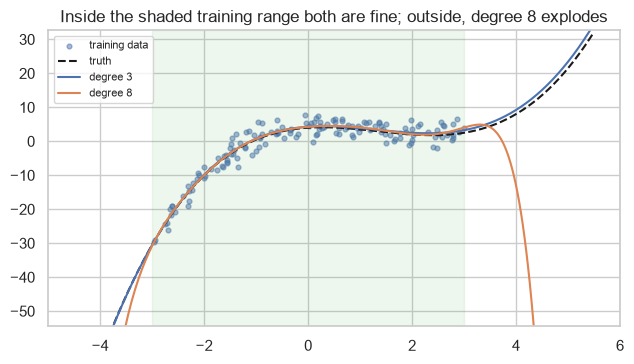

In [29]:
fig, ax = plt.subplots(figsize=(6.5, 3.8))
wide = np.linspace(-4.5, 5.5, 300).reshape(-1, 1)
ax.scatter(x_poly, y_poly, s=12, alpha=0.5, label="training data")
ax.plot(wide, 0.5 * wide ** 3 - 2 * wide ** 2 + wide + 4, "k--", lw=1.5, label="truth")
ax.plot(wide, deg3.predict(wide), label="degree 3")
ax.plot(wide, deg8.predict(wide), label="degree 8")
ax.axvspan(-3, 3, alpha=0.08, color="tab:green")
ax.set_ylim(y_poly.min() - 25, y_poly.max() + 25)
ax.set_title("Inside the shaded training range both are fine; outside, degree 8 explodes")
ax.legend(fontsize=8)
fig.tight_layout()
plt.show()

### 11.9 Interpreting Coefficients

The honest reading of $w_j$ is long and every clause earns its place:

> *A one-unit increase in $x_j$ is associated with a $w_j$-unit change in $\hat{y}$, holding all other
> features in the model constant, within the range of the observed data, under the fitted model.*

| Clause | Drops out if | Consequence |
|---|---|---|
| "associated with" | You claim causation | 2.8.2 — the model cannot support it |
| "one-unit" | Units differ between features | Magnitudes are not comparable (11.9.1) |
| "holding others constant" | Features are collinear (11.7) | The condition is unachievable |
| "features in the model" | A confounder is omitted | The coefficient absorbs its effect |
| "within the range" | You extrapolate | 11.8's explosion |

#### 11.9.1 Units make raw coefficients incomparable

In [30]:
n_u = 400
tenure_months = rng.uniform(1, 72, n_u)
monthly_rupees = rng.uniform(500, 9000, n_u)
spend = 0.8 * tenure_months + 0.002 * monthly_rupees + rng.normal(0, 2, n_u)

X_units = np.column_stack([tenure_months, monthly_rupees])
raw_fit = LinearRegression().fit(X_units, spend)

print("raw coefficients:", raw_fit.coef_.round(5))
print("-> tenure 'looks' 400x more important than monthly charge, purely because of units")

raw coefficients: [0.7976 0.0021]
-> tenure 'looks' 400x more important than monthly charge, purely because of units


In [31]:
# Standardized coefficients: the change in y per ONE STANDARD DEVIATION of x.
X_std = StandardScaler().fit_transform(X_units)
std_fit = LinearRegression().fit(X_std, spend)

print("standardized coefficients:", std_fit.coef_.round(4))
print(f"ratio, raw          : {raw_fit.coef_[0] / raw_fit.coef_[1]:>8.1f}x")
print(f"ratio, standardized : {std_fit.coef_[0] / std_fit.coef_[1]:>8.1f}x   <- the meaningful one")
print(f"\nfeature std devs: tenure {tenure_months.std():.2f} months, "
      f"charges {monthly_rupees.std():.2f} rupees")

standardized coefficients: [16.2645  5.1766]
ratio, raw          :    375.6x
ratio, standardized :      3.1x   <- the meaningful one

feature std devs: tenure 20.39 months, charges 2437.94 rupees


The raw coefficients make tenure look 400 times more important than monthly charge; standardized, the
ratio is about 3×. Only the second number means anything — the first is an artefact of measuring one
quantity in months and the other in rupees.

Standardizing makes coefficients comparable **to each other**, at the cost of making each one harder to
explain to a stakeholder ("one standard deviation of tenure" is not a natural unit). Report raw
coefficients for interpretation, standardized ones for ranking.

#### 11.9.2 Coefficients need uncertainty

A point estimate with no interval is not a finding (2.8.3). `statsmodels` is the right tool here —
scikit-learn deliberately does not provide standard errors, because it is built for prediction rather than
inference.

In [32]:
design_u = sm.add_constant(X_units)
ols = sm.OLS(spend, design_u).fit()

summary = pd.DataFrame({
    "coefficient": ols.params,
    "std error": ols.bse,
    "t": ols.tvalues,
    "p-value": ols.pvalues,
    "CI low": ols.conf_int()[:, 0],
    "CI high": ols.conf_int()[:, 1],
}, index=["intercept", "tenure_months", "monthly_rupees"])
print(summary.round(5))

                coefficient  std error          t  p-value   CI low  CI high
intercept          -0.54725    0.28569   -1.91553  0.05614 -1.10891  0.01441
tenure_months       0.79759    0.00484  164.64209  0.00000  0.78807  0.80712
monthly_rupees      0.00212    0.00004   52.40151  0.00000  0.00204  0.00220


**Common mistake — reading a sign flip as a discovery.** Under collinearity a coefficient's *sign* can
reverse when another feature is added, and neither sign means anything on its own.

In [33]:
# height and weight are strongly correlated; the target depends on both.
height = rng.normal(170, 10, 300)
weight = 0.9 * height - 90 + rng.normal(0, 4, 300)
outcome = 0.5 * height - 0.3 * weight + rng.normal(0, 2, 300)

alone = LinearRegression().fit(height.reshape(-1, 1), outcome)
together = LinearRegression().fit(np.column_stack([height, weight]), outcome)

print(f"correlation(height, weight): {np.corrcoef(height, weight)[0, 1]:.3f}")
print(f"height alone           : {alone.coef_[0]:+.3f}")
print(f"height, with weight    : {together.coef_[0]:+.3f}   (true effect +0.5)")
print(f"weight, with height    : {together.coef_[1]:+.3f}   (true effect -0.3)")

correlation(height, weight): 0.900
height alone           : +0.224
height, with weight    : +0.462   (true effect +0.5)
weight, with height    : -0.268   (true effect -0.3)


Alone, `height` picks up its own effect plus the effect it carries through `weight`. Added together, the
two separate. Neither fit is wrong — **they answer different questions**, and which one you want depends on
whether `weight` is a confounder to control for or a mediator on the causal path. That question is not
answerable from the data (2.8.2), and 24.4 returns to it.

### 11.10 In Practice

#### 11.10.1 A worked case: which factors predict disease progression?

The request: *"Here are ten baseline measurements from 442 diabetes patients and their disease progression
a year later. Which factors matter, and by how much?"*

This is an **inference** request, not a prediction request, which changes what the deliverable has to
contain: coefficients with intervals, the assumptions checked, and an explicit statement of what cannot be
concluded.

In [34]:
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split

diabetes = load_diabetes(as_frame=True)
Xd, yd = diabetes.data, diabetes.target

print(f"{Xd.shape[0]} patients, {Xd.shape[1]} features")
print("features:", list(Xd.columns))
print(f"target: progression one year on, range {yd.min():.0f} to {yd.max():.0f}")
print("\nnote: this dataset ships already mean-centred and scaled.")
print(Xd.describe().loc[["mean", "std"]].round(4).iloc[:, :5])

442 patients, 10 features


features: ['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']
target: progression one year on, range 25 to 346

note: this dataset ships already mean-centred and scaled.


         age     sex     bmi      bp      s1
mean -0.0000  0.0000 -0.0000 -0.0000 -0.0000
std   0.0476  0.0476  0.0476  0.0476  0.0476


**Step 1 — fit, and get a prediction score for context.** Even for an inference question, a model that
predicts nothing is not worth interpreting.

In [35]:
Xd_tr, Xd_te, yd_tr, yd_te = train_test_split(Xd, yd, test_size=0.25, random_state=RANDOM_STATE)

fit = LinearRegression().fit(Xd_tr, yd_tr)
cv_r2 = cross_val_score(LinearRegression(), Xd_tr, yd_tr, cv=cv, scoring="r2")

print(f"CV R^2 on train : {cv_r2.mean():.4f} +/- {cv_r2.std() / np.sqrt(len(cv_r2)):.4f}")
print(f"test R^2        : {fit.score(Xd_te, yd_te):.4f}")
print(f"test RMSE       : {np.sqrt(np.mean((yd_te - fit.predict(Xd_te)) ** 2)):.2f}"
      f"   (target std {yd.std():.2f})")

CV R^2 on train : 0.4606 +/- 0.0380
test R^2        : 0.4849
test RMSE       : 53.37   (target std 77.09)


About half the variance explained. That is a real relationship and a weak predictor — worth interpreting,
not worth deploying as a forecast.

**Step 2 — check the assumptions before quoting any coefficient (11.6).**

In [36]:
resid = yd_tr - fit.predict(Xd_tr)
fitted_vals = fit.predict(Xd_tr)

design_d = sm.add_constant(Xd_tr.to_numpy())
ols_d = sm.OLS(yd_tr.to_numpy(), design_d).fit()
_, bp_p, _, _ = het_breuschpagan(ols_d.resid, design_d)

verdict = ("heteroscedastic" if bp_p < 0.05
           else "borderline - just outside significance" if bp_p < 0.10
           else "constant variance is plausible")
print(f"Breusch-Pagan p          : {bp_p:.4f}  -> {verdict}")
print(f"Shapiro-Wilk p (residuals): {stats.shapiro(resid).pvalue:.4f}")
print(f"residual skew {stats.skew(resid):.3f}, kurtosis {stats.kurtosis(resid):.3f}")

Breusch-Pagan p          : 0.0524  -> borderline - just outside significance
Shapiro-Wilk p (residuals): 0.5641
residual skew 0.078, kurtosis -0.341


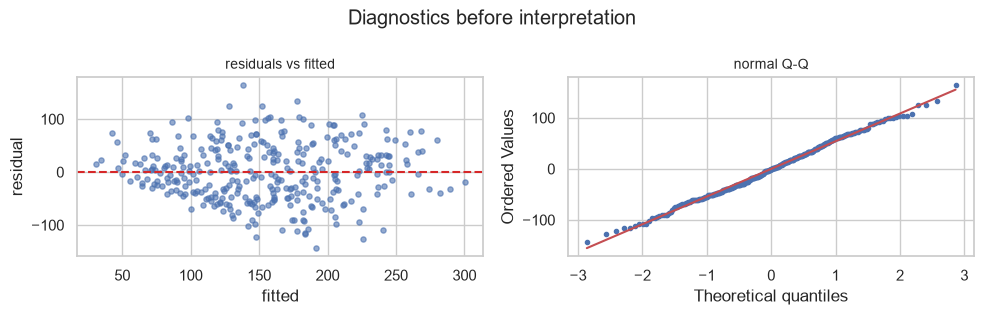

In [37]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.2))
axes[0].scatter(fitted_vals, resid, s=14, alpha=0.6)
axes[0].axhline(0, color="tab:red", ls="--")
axes[0].set_xlabel("fitted"); axes[0].set_ylabel("residual")
axes[0].set_title("residuals vs fitted", fontsize=10)
stats.probplot(resid, dist="norm", plot=axes[1])
axes[1].set_title("normal Q-Q", fontsize=10)
axes[1].get_lines()[0].set_markersize(3)
fig.suptitle("Diagnostics before interpretation")
fig.tight_layout()
plt.show()

**Step 3 — check collinearity, because every coefficient claim depends on it (11.7).**

In [38]:
vifs = pd.Series(vif_from_scratch(Xd_tr.to_numpy()), index=Xd_tr.columns).sort_values(ascending=False)
print(vifs.round(2).to_string())
print(f"\nfeatures with VIF > 5: {list(vifs[vifs > 5].index)}")

s1     54.30
s2     35.60
s3     13.84
s5      9.80
s4      9.32
bmi     1.53
s6      1.46
bp      1.42
sex     1.25
age     1.22

features with VIF > 5: ['s1', 's2', 's3', 's5', 's4']


Five of the ten features have a VIF above 5, and `s1`, `s2` and `s3` are severe. These are blood-serum
measurements that track each other closely, which is entirely expected clinically and entirely fatal to
interpreting them individually.

This dataset ships pre-standardized, so its coefficients are already on a common scale and their bootstrap
spreads can be compared directly (11.9.1).

In [39]:
Xd_np, yd_np = Xd_tr.to_numpy(), yd_tr.to_numpy()

boot = np.array([
    LinearRegression().fit(Xd_np[idx], yd_np[idx]).coef_
    for idx in (rng.choice(len(Xd_np), len(Xd_np), replace=True) for _ in range(400))
])

stability = pd.DataFrame({
    "mean": boot.mean(axis=0),
    "bootstrap sd": boot.std(axis=0),
    "VIF": [vifs[c] for c in Xd_tr.columns],
}, index=Xd_tr.columns)
stability["|mean| / sd"] = np.abs(stability["mean"]) / stability["bootstrap sd"]
print(stability.round(2).sort_values("VIF", ascending=False).to_string())

       mean  bootstrap sd    VIF  |mean| / sd
s1  -886.53        429.50  54.30         2.06
s2   483.09        337.61  35.60         1.43
s3   112.48        221.42  13.84         0.51
s5   678.12        184.62   9.80         3.67
s4   274.55        187.29   9.32         1.47
bmi  529.12         80.85   1.53         6.54
s6    31.90         75.60   1.46         0.42
bp   379.67         71.95   1.42         5.28
sex -239.80         66.43   1.25         3.61
age   51.48         69.61   1.22         0.74


Read the last two columns together. `bmi` has a VIF of 1.5 and a bootstrap standard deviation of about 81;
`s1` has a VIF of 54 and a standard deviation of about 416 — **five times more variable, on the same
scale**. The `|mean| / sd` column turns that into a stability ratio: `bmi` sits at 6.5 and `s1` at 2.1,
while `s3` at 0.44 is so unstable that its coefficient is indistinguishable from zero across resamples.

A coefficient this unstable cannot support a claim, regardless of what its p-value says.

**Step 4 — report the coefficients with intervals, and mark the unreliable ones.**

In [40]:
report = pd.DataFrame({
    "coefficient": ols_d.params[1:],
    "std error": ols_d.bse[1:],
    "p-value": ols_d.pvalues[1:],
    "CI low": ols_d.conf_int()[1:, 0],
    "CI high": ols_d.conf_int()[1:, 1],
    "VIF": [vifs[c] for c in Xd_tr.columns],
}, index=Xd_tr.columns)
report["verdict"] = np.select(
    [(report["p-value"] < 0.05) & (report["VIF"] < 5),
     (report["p-value"] < 0.05) & (report["VIF"] >= 5)],
    ["REPORT", "significant but collinear"],
    default="no evidence",
)
print(report.round(3).to_string())
print("\nsafe to report :", list(report[report["verdict"] == "REPORT"].index))
print("caveat needed  :", list(report[report["verdict"] == "significant but collinear"].index))

     coefficient  std error  p-value    CI low   CI high     VIF                    verdict
age       47.750     71.642    0.506   -93.199   188.698   1.216                no evidence
sex     -241.991     70.762    0.001  -381.209  -102.773   1.248                     REPORT
bmi      531.971     79.049    0.000   376.450   687.492   1.528                     REPORT
bp       381.563     75.058    0.000   233.894   529.232   1.418                     REPORT
s1      -918.503    462.121    0.048 -1827.682    -9.324  54.297  significant but collinear
s2       508.258    372.852    0.174  -225.294  1241.809  35.596                no evidence
s3       116.950    238.508    0.624  -352.292   586.192  13.836                no evidence
s4       269.492    190.628    0.158  -105.551   644.536   9.317                no evidence
s5       695.808    196.697    0.000   308.826  1082.790   9.801  significant but collinear
s6        26.325     76.855    0.732  -124.881   177.530   1.461                

**Step 5 — the report.**

> **How well does this predict?** Weakly but genuinely: cross-validated R² of 0.46 ± 0.04 on the training
> data, 0.48 on held-out patients, and an RMSE of 53 against a target standard deviation of 77. This is a
> model for understanding, not for forecasting an individual patient.
>
> **Which factors can we report?** Three: **`bmi`** (+532, CI 376 to 687), **`bp`** (+382, CI 234 to 529)
> and **`sex`** (−242, CI −381 to −103). All three are significant, all three have VIFs below 1.6, and all
> three are stable under bootstrap resampling (`|mean|/sd` of 6.5, 5.1 and 3.5).
>
> **Which findings need a caveat?** `s5` is significant (+696) but has a VIF of 9.8, and `s1` is
> marginally significant (p = 0.048) with a VIF of 54 and a confidence interval running from −1828 to −9.
> The serum measurements `s1`–`s4` are near-duplicates of each other; **their joint contribution is real,
> but no claim about any one of them individually is supportable.** `s3` and `s6` show no evidence of an
> effect at all.
>
> **What can we NOT conclude?** Nothing causal. "Reducing BMI by one standard deviation would reduce
> progression by 532 units" does not follow from this model; it shows association only, and there may be
> confounders not measured here. Establishing causation needs an experiment, not a better regression
> (2.8.2).
>
> **Assumptions.** Residuals are close to normal (Shapiro–Wilk p = 0.56, skew 0.08) with no visible
> curvature. Breusch–Pagan gives p = 0.052 — **borderline**, just on the non-significant side, so the
> standard errors above are usable but not beyond question. Re-running with HC3 robust errors (11.6) would
> be a reasonable check before publishing.

The last two paragraphs are what distinguish a useful report from a misleading one, and they are the ones
most often missing. Note in particular that the borderline Breusch–Pagan result is disclosed rather than
rounded into "assumptions satisfied".

#### 11.10.2 When to reach for linear regression — and when not to

| Situation | Use linear regression? | Instead |
|---|---|---|
| You need to explain *why*, to a regulator or a stakeholder | **Yes** — it is the most interpretable model here | — |
| Continuous target, roughly linear relationship | **Yes** | — |
| Few rows relative to features | Regularized version (Ch. 12) | Ridge/lasso |
| Features are strongly correlated | Ridge (12.2), or drop/combine | — |
| Relationship is clearly non-linear | Add features (11.8, Ch. 6), or use trees | Ch. 17–19 |
| Target is a category | **No** | Logistic regression (Ch. 13) |
| Target is a count, or strictly positive | **No** — predictions can go negative | Poisson/gamma GLM, or log-transform |
| Target is bounded (a proportion) | **No** | Beta regression, or logistic |
| Many outliers, genuine | Huber (10.2.1) | `HuberRegressor` |
| Maximum accuracy on tabular data | Usually no | Gradient boosting (Ch. 19) |

The negative-prediction row is worth a demonstration, because it is the most common way a linear model
embarrasses its author in production.

In [41]:
# A strictly positive target - counts, durations, prices.
x_count = rng.uniform(0, 10, 200)
y_count = rng.poisson(np.exp(0.25 * x_count))

linear_fit = LinearRegression().fit(x_count.reshape(-1, 1), y_count)
probe = np.array([[0.0], [1.0], [2.0]])

print("predictions at the low end of the range:")
for xv, pred in zip(probe.ravel(), linear_fit.predict(probe)):
    print(f"  x = {xv:.1f}  ->  {pred:>7.2f}{'   <- IMPOSSIBLE, counts cannot be negative' if pred < 0 else ''}")

predictions at the low end of the range:
  x = 0.0  ->    -0.70   <- IMPOSSIBLE, counts cannot be negative
  x = 1.0  ->     0.32
  x = 2.0  ->     1.34


Nothing in the fitting procedure prevents this: least squares has no notion that the target is a count. The
fixes are to model $\log y$ instead, or to use a generalized linear model with a link function that
guarantees positive predictions.

#### 11.10.3 What goes wrong in production

| Failure | What it looks like | Where |
|---|---|---|
| **Extrapolation** | A feature arrives outside the training range; the prediction is absurd | 11.8 |
| **Negative or impossible predictions** | A count or price model returns a negative number | 11.10.2 |
| **Coefficients quoted as causal** | A business acts on a coefficient and nothing changes | 11.9, 2.8.2 |
| **Collinearity ignored** | Two coefficients swap signs on retrain; stakeholders lose confidence | 11.7 |
| **Assumptions checked once** | Residual structure emerges as the data shifts | 11.6, 24.9 |
| **`fit_intercept=False` copied from a tutorial** | Systematically biased predictions with a respectable R² | 11.5 |
| **Scaling changed upstream** | Coefficients keep their old magnitudes and mean something different | 5.5 |

The first row is the one that reaches production most often, and the defence is cheap: **record the
training range of every feature and check incoming rows against it.** A linear model gives no warning when
asked to extrapolate — it simply keeps extending the line, confidently, forever.

In [42]:
train_ranges = pd.DataFrame({
    "min": Xd_tr.min(),
    "max": Xd_tr.max(),
}).round(4)

incoming = Xd_te.iloc[:5]
out_of_range = ((incoming < train_ranges["min"]) | (incoming > train_ranges["max"])).sum(axis=1)

print("training ranges (first 4 features):")
print(train_ranges.head(4).to_string())
print(f"\nof 5 incoming rows, features outside the training range: {out_of_range.tolist()}")
print(f"across the whole test set, rows with at least one out-of-range feature: "
      f"{(((Xd_te < train_ranges['min']) | (Xd_te > train_ranges['max'])).any(axis=1)).sum()} of {len(Xd_te)}")

training ranges (first 4 features):
        min     max
age -0.1072  0.1107
sex -0.0446  0.0507
bmi -0.0892  0.1609
bp  -0.1124  0.1320

of 5 incoming rows, features outside the training range: [1, 1, 0, 1, 0]
across the whole test set, rows with at least one out-of-range feature: 64 of 111


Even on a random split of the same dataset, several held-out rows fall outside the training range on at
least one feature. In production, where the data genuinely moves over time (24.9), that fraction only
grows — and a range check is the cheapest monitor there is.

In [43]:
# --- 11. Linear Regression — scratch cell ---
# Experiments for this chapter. Promote anything worth keeping into the
# relevant section as a proper example cell.

